# L2 Pandas I: Basics

- Dataframes
- Indices
- Attributes
- Slicing (Labels & Indices & `[]`)

## 1. Dataframes

### Creation

In [113]:
import pandas as pd
elections = pd.read_csv("elections.csv")
elections
# The code above code stores our DataFrame object in the elections variable

,Year,Candidate,Party,Popular vote,Result,%
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878
2,1828,Andrew Jackson,Democratic,642806,win,56.203927
3,1828,John Quincy Adams,National Republican,500897,loss,43.796073
4,1832,Andrew Jackson,Democratic,702735,win,54.574789
...,...,...,...,...,...,...
182,2024,Donald Trump,Republican,77303568,win,49.808629
183,2024,Kamala Harris,Democratic,75019230,loss,48.336772
184,2024,Jill Stein,Green,861155,loss,0.554864
185,2024,Robert Kennedy,Independent,756383,loss,0.487357


We can also create df with our own data

In [114]:
df_list = pd.DataFrame([1, 2, 3], columns=["Numbers"]) # cols need nesting since it presumes multiple ones
df_list

,Numbers
0,1
1,2
2,3


Notice how a 2D list of values is required to initialize the second DataFrame — each nested list represents a single row of data

In [115]:
df_list = pd.DataFrame([[1, "one"], [2, "two"]], columns = ["Number", "Description"])
df_list
# Whenever more than one cols/rows, that means it is iterable and should be nested

,Number,Description
0,1,one
1,2,two


We can also use iterables to create df

**2 Ways to Do It using Dictionaries**
- One Dict
    - Keys (Cols): Iterable Values (data for each entry)

- Multiple Dicts
    - [
        {Col 1: Value 1.1, Col 2: Value 1.2} # Observation 1
        
        {Col 1: Value 2.1, Col 2: Value 2.2} # Observation 2
      ]


In [116]:
df_dict = pd.DataFrame(
    {"Fruits": ['Apple', 'Banana', 'Cherry'], 
     "Colors": ['Red', 'Yellow', 'Red']}
)
df_dict

,Fruits,Colors
0,Apple,Red
1,Banana,Yellow
2,Cherry,Red


In [117]:
df_dict = pd.DataFrame(
    [
        {"Fruits": "Apple", "Color": "Red"},
        {"Fruits": "Banana", "Color": "Yellow"}
    ]
)
df_dict

,Fruits,Color
0,Apple,Red
1,Banana,Yellow


<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

We can see the latter method is more redundant and cumbersome since we need to write a lot of repetitive keys

**Use first one when possible**

</div>

We can use Series to form Dataframe

Since Dataframe is just a collecion of Series

In [118]:
# Two Series
s_a = pd.Series([1, 2, 3], index=["r1", "r2", "r3"])
s_b = pd.Series(['a', 'b', 'c'], index=["r1", "r2", "r3"])

In [119]:
s_a

r1    1
r2    2
r3    3
dtype: int64

We can turn single Series into Dataframe (i.e. df with only one col)

In [120]:
pd.DataFrame(s_a) # We can treat a Series as a iterables and convert it
# It is more general

,0
r1,1
r2,2
r3,3


In [121]:
s_b.to_frame() # We can also convert the Series directly to df
# It is more specific to Series class

,0
r1,a
r2,b
r3,c


<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> **Series and One-col Dataframe**

- They visualized in the same way since the intepreter will automatically visualize Series as if it is a dataframe

- But they are different, Series don't have "col", it can have a name but name is not the col! (Though through visualization it shows a 0 as the col but that is because it is converted into df first and during this process it is automatically signed with a col name 0. And if the Series has a name, this process will automatically sign the name as the col name in df) 

</div>

We can merge multiple Series into df

In [122]:
pd.DataFrame({
    "A_column": s_a,
    "B_column": s_b
}
)

,A_column,B_column
r1,1,a
r2,2,b
r3,3,c


## 2. Indices

Indices do not have to be a Integer

**It even do not have to be unique!**

In [123]:
# Creating a DataFrame from a CSV file and specifying the index column
elections = pd.read_csv("elections.csv", index_col="Candidate")
elections

,Year,Party,Popular vote,Result,%
Candidate,,,,,
Andrew Jackson,1824,Democratic-Republican,151271,loss,57.210122
John Quincy Adams,1824,Democratic-Republican,113142,win,42.789878
Andrew Jackson,1828,Democratic,642806,win,56.203927
John Quincy Adams,1828,National Republican,500897,loss,43.796073
Andrew Jackson,1832,Democratic,702735,win,54.574789
...,...,...,...,...,...
Donald Trump,2024,Republican,77303568,win,49.808629
Kamala Harris,2024,Democratic,75019230,loss,48.336772
Jill Stein,2024,Green,861155,loss,0.554864


Let's compare with the initial one

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Year</th>
      <th>Candidate</th>
      <th>Party</th>
      <th>Popular vote</th>
      <th>Result</th>
      <th>%</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1824</td>
      <td>Andrew Jackson</td>
      <td>Democratic-Republican</td>
      <td>151271</td>
      <td>loss</td>
      <td>57.210122</td>
    </tr>
    <tr>
      <th>1</th>
      <td>1824</td>
      <td>John Quincy Adams</td>
      <td>Democratic-Republican</td>
      <td>113142</td>
      <td>win</td>
      <td>42.789878</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1828</td>
      <td>Andrew Jackson</td>
      <td>Democratic</td>
      <td>642806</td>
      <td>win</td>
      <td>56.203927</td>
    </tr>
    <tr>
      <th>3</th>
      <td>1828</td>
      <td>John Quincy Adams</td>
      <td>National Republican</td>
      <td>500897</td>
      <td>loss</td>
      <td>43.796073</td>
    </tr>
    <tr>
      <th>4</th>
      <td>1832</td>
      <td>Andrew Jackson</td>
      <td>Democratic</td>
      <td>702735</td>
      <td>win</td>
      <td>54.574789</td>
    </tr>
    <tr>
      <th>...</th>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
      <td>...</td>
    </tr>
    <tr>
      <th>182</th>
      <td>2024</td>
      <td>Donald Trump</td>
      <td>Republican</td>
      <td>77303568</td>
      <td>win</td>
      <td>49.808629</td>
    </tr>
    <tr>
      <th>183</th>
      <td>2024</td>
      <td>Kamala Harris</td>
      <td>Democratic</td>
      <td>75019230</td>
      <td>loss</td>
      <td>48.336772</td>
    </tr>
    <tr>
      <th>184</th>
      <td>2024</td>
      <td>Jill Stein</td>
      <td>Green</td>
      <td>861155</td>
      <td>loss</td>
      <td>0.554864</td>
    </tr>
    <tr>
      <th>185</th>
      <td>2024</td>
      <td>Robert Kennedy</td>
      <td>Independent</td>
      <td>756383</td>
      <td>loss</td>
      <td>0.487357</td>
    </tr>
    <tr>
      <th>186</th>
      <td>2024</td>
      <td>Chase Oliver</td>
      <td>Libertarian Party</td>
      <td>650130</td>
      <td>loss</td>
      <td>0.418895</td>
    </tr>
  </tbody>
</table>
<p>187 rows × 6 columns</p>
</div>

- The "Indices Col" now has a col name instead of vacuum

- **We can mannually pick the col we want to be the indices!**

We can also RESET the indices col

In [124]:
# Resetting the index so we can set it again
elections.reset_index(inplace = True)
elections

,Candidate,Year,Party,Popular vote,Result,%
0,Andrew Jackson,1824,Democratic-Republican,151271,loss,57.210122
1,John Quincy Adams,1824,Democratic-Republican,113142,win,42.789878
2,Andrew Jackson,1828,Democratic,642806,win,56.203927
3,John Quincy Adams,1828,National Republican,500897,loss,43.796073
4,Andrew Jackson,1832,Democratic,702735,win,54.574789
...,...,...,...,...,...,...
182,Donald Trump,2024,Republican,77303568,win,49.808629
183,Kamala Harris,2024,Democratic,75019230,loss,48.336772
184,Jill Stein,2024,Green,861155,loss,0.554864
185,Robert Kennedy,2024,Independent,756383,loss,0.487357


In [125]:
# This sets the index to the "Party" column
elections.set_index("Party")

,Candidate,Year,Popular vote,Result,%
Party,,,,,
Democratic-Republican,Andrew Jackson,1824,151271,loss,57.210122
Democratic-Republican,John Quincy Adams,1824,113142,win,42.789878
Democratic,Andrew Jackson,1828,642806,win,56.203927
National Republican,John Quincy Adams,1828,500897,loss,43.796073
Democratic,Andrew Jackson,1832,702735,win,54.574789
...,...,...,...,...,...
Republican,Donald Trump,2024,77303568,win,49.808629
Democratic,Kamala Harris,2024,75019230,loss,48.336772
Green,Jill Stein,2024,861155,loss,0.554864


## 3. Attributes

- Index
- Columns
- Shape

In [126]:
elections = pd.read_csv("elections.csv")
elections.set_index("Party", inplace = True) # See below
elections

,Year,Candidate,Popular vote,Result,%
Party,,,,,
Democratic-Republican,1824,Andrew Jackson,151271,loss,57.210122
Democratic-Republican,1824,John Quincy Adams,113142,win,42.789878
Democratic,1828,Andrew Jackson,642806,win,56.203927
National Republican,1828,John Quincy Adams,500897,loss,43.796073
Democratic,1832,Andrew Jackson,702735,win,54.574789
...,...,...,...,...,...
Republican,2024,Donald Trump,77303568,win,49.808629
Democratic,2024,Kamala Harris,75019230,loss,48.336772
Green,2024,Jill Stein,861155,loss,0.554864


**Index**

It helps you to get all data of indices

In [127]:
elections.index

Index(['Democratic-Republican', 'Democratic-Republican', 'Democratic',
       'National Republican', 'Democratic', 'National Republican',
       'Anti-Masonic', 'Whig', 'Democratic', 'Whig',
       ...
       'Green', 'Democratic', 'Republican', 'Libertarian', 'Green',
       'Republican', 'Democratic', 'Green', 'Independent',
       'Libertarian Party'],
      dtype='object', name='Party', length=187)

**Columns**

It gives you a list of names of all columns

In [128]:
elections.columns

Index(['Year', 'Candidate', 'Popular vote', 'Result', '%'], dtype='object')

**Shape**

It tells you the ***row x col*** of the df

(# of Observations x # of Columns)

In [129]:
elections.shape

(187, 5)

<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong>

Caveat! The "indices col" is not counted as a true col! So it does not contribute to the # of cols

</div>

## 4. ***Slicing*** in DataFrame***s***

**We wanna extract part of data from a df**

- *First / Last n* observations: `.head` and `.tail`

- Data with *certain labels*: `.loc`

- *Certain position / location*: `.iloc`

- Some *shortcuts*: `[]`

### 4.1 First / Last n Observations

We use `.head` and `.tail`

In [130]:
elections = pd.read_csv("elections.csv")

In [131]:
# Extract the first 5 rows of the DataFrame
elections.head(5)

,Year,Candidate,Party,Popular vote,Result,%
0,1824,Andrew Jackson,Democratic-Republican,151271,loss,57.210122
1,1824,John Quincy Adams,Democratic-Republican,113142,win,42.789878
2,1828,Andrew Jackson,Democratic,642806,win,56.203927
3,1828,John Quincy Adams,National Republican,500897,loss,43.796073
4,1832,Andrew Jackson,Democratic,702735,win,54.574789


In [132]:
# Extract the last 5 rows of the DataFrame
elections.tail(5)

,Year,Candidate,Party,Popular vote,Result,%
182,2024,Donald Trump,Republican,77303568,win,49.808629
183,2024,Kamala Harris,Democratic,75019230,loss,48.336772
184,2024,Jill Stein,Green,861155,loss,0.554864
185,2024,Robert Kennedy,Independent,756383,loss,0.487357
186,2024,Chase Oliver,Libertarian Party,650130,loss,0.418895


### 4.2 **Label-based** Extraction

We use `.loc`

- Inclusive 

<div style="background-color:#3b82f630; padding:12px 16px; border-left:5px solid #3b82f6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Definition:</strong> **Labels**

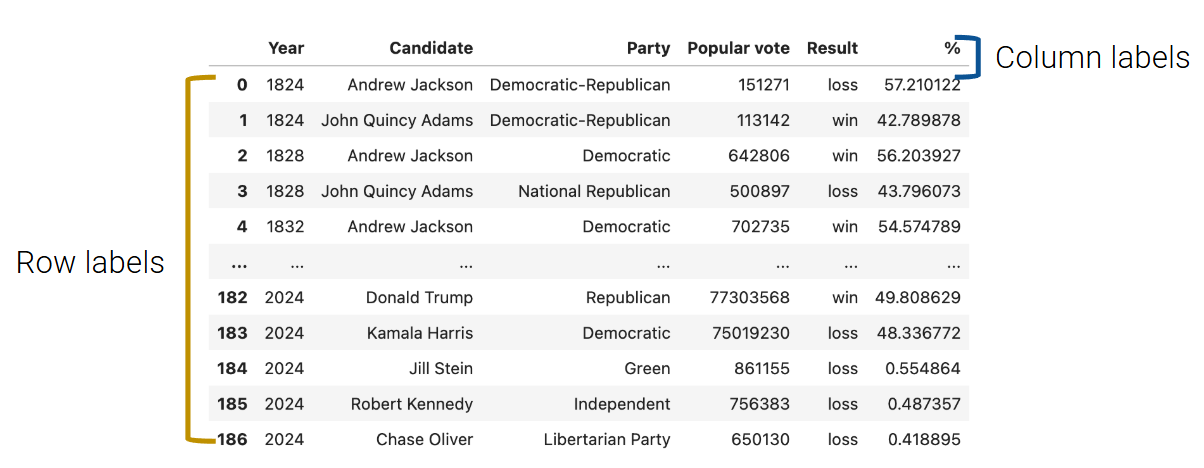

The `.loc` accessor allows us to specify the labels of rows and columns we wish to extract. 

- The **row labels** (indices) are the bold text on the far left of a DataFrame

- The **column labels** are the column names found at the top of a DataFrame

</div>

**`.loc`** takes [rows, cols]

**3 Things to pass into the `.loc`**

- Single index
- Seq of indices
- Slice Objects

In [133]:
# Single index
elections.loc[1, "Candidate"]
# It yields a single data point

'John Quincy Adams'

In [134]:
# Seq of indices
elections.loc[[1,3,5], ["Candidate", "Party"]]
# Multiple cols yield a df


,Candidate,Party
1,John Quincy Adams,Democratic-Republican
3,John Quincy Adams,National Republican
5,Henry Clay,National Republican


In [135]:
print(type(elections.loc[[1,2,3],"Candidate"]))
elections.loc[[1,2,3],"Candidate"]
# Single col data point yields a Series

<class 'pandas.core.series.Series'>


1    John Quincy Adams
2       Andrew Jackson
3    John Quincy Adams
Name: Candidate, dtype: object

In [136]:
# but single-element seq yields a df
print(type(elections.loc[[1,2,3],["Candidate"]]))
elections.loc[[1,2,3],["Candidate"]]

<class 'pandas.core.frame.DataFrame'>


,Candidate
1,John Quincy Adams
2,Andrew Jackson
3,John Quincy Adams


<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> **Series or DataFrame?**

- If it is a single data point, it is Series

- If it is a seq, it is df

</div>

In [137]:
# Slicing
elections.loc[1:3, 'Candidate']
# It yields a Series

1    John Quincy Adams
2       Andrew Jackson
3    John Quincy Adams
Name: Candidate, dtype: object

<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> 

For slicing in df, it INCLUDES the last label! It is **inclusive**

</div>

In [138]:
# Slicing
elections.loc[1:3, ['Candidate', 'Party']]
# It yields a DataFrame

,Candidate,Party
1,John Quincy Adams,Democratic-Republican
2,Andrew Jackson,Democratic
3,John Quincy Adams,National Republican


In [139]:
elections.loc[1:3, 1:3]

TypeError: cannot do slice indexing on Index with these indexers [1] of type int

<div style="background-color:#ef444426; padding:12px 16px; border-left:5px solid #ef4444; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Warning:</strong> 

- cols can not use locaiton index-based slicing by `.loc`!
    - We need to use `.iloc` instead
    - Caveat: Here we using 1:3 does not mean they are position indices (though it looks alike). They are numeric ***labels***! If we set the indices col into other, say text-based indices, then it won't work and we need to use something similar to the col slicing here below

- But we can specify the col names to do slicing


</div>

In [140]:
elections.loc[1:3, "Candidate":"Result"]

,Candidate,Party,Popular vote,Result
1,John Quincy Adams,Democratic-Republican,113142,win
2,Andrew Jackson,Democratic,642806,win
3,John Quincy Adams,National Republican,500897,loss


In [141]:
elections.set_index("Candidate", inplace = True)
elections

,Year,Party,Popular vote,Result,%
Candidate,,,,,
Andrew Jackson,1824,Democratic-Republican,151271,loss,57.210122
John Quincy Adams,1824,Democratic-Republican,113142,win,42.789878
Andrew Jackson,1828,Democratic,642806,win,56.203927
John Quincy Adams,1828,National Republican,500897,loss,43.796073
Andrew Jackson,1832,Democratic,702735,win,54.574789
...,...,...,...,...,...
Donald Trump,2024,Republican,77303568,win,49.808629
Kamala Harris,2024,Democratic,75019230,loss,48.336772
Jill Stein,2024,Green,861155,loss,0.554864


In [142]:
# Then it won't work for "1:3" slicing
elections.loc[1:3, "Party"]

TypeError: cannot do slice indexing on Index with these indexers [1] of type int

#### Extras

<div style="background-color:#8b5cf630; padding:12px 16px; border-left:5px solid #8b5cf6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Question:</strong> 

But for indices, it can be repetitive, what will happen it we just use label slicing for rows?

</div>

In [ ]:
df1 = pd.DataFrame({
    "A": [1, 2, 3, 4, 5],
    "B": ["a", "b", "b", "c", "c"],
    "C": [4, 5, 6, 7, 8]
})
df1.set_index("B", inplace=True)
df1

,A,C
B,,
a,1,4
b,2,5
b,3,6
c,4,7
c,5,8


In [ ]:
df1.loc["b"] # i.e. df1.loc["b", :]

,A,C
B,,
b,2,5
b,3,6


In [ ]:
df1.loc["b":"c", :]

,A,C
B,,
b,2,5
b,3,6
c,4,7
c,5,8


In [ ]:
df1.loc["a":"b", :]

,A,C
B,,
a,1,4
b,2,5
b,3,6


<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

When same labels are grouped together, we treat them as one and expand it later after slicing

</div>

In [ ]:
df2 = pd.DataFrame({
    "A": [1, 2, 3, 4, 5],
    "B": ["a", "b", "c", "b", "c"],
    "C": [4, 5, 6, 7, 8]
})
df2.set_index("B", inplace=True)
df2

,A,C
B,,
a,1,4
b,2,5
c,3,6
b,4,7
c,5,8


In [ ]:
df2.loc["b":"c", :]

KeyError: "Cannot get left slice bound for non-unique label: 'b'"

In [ ]:
df2.loc["a":"b", :]

KeyError: "Cannot get right slice bound for non-unique label: 'b'"

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> 

If any repetitive labels are not grouped together, it will just call an error

</div>

Since col labels are unique, row labels are not necessarily the case, to make our life simpler, just don't use label slicing for non-unqiue row labels!

### 4.3 **Index-Based** Extraction

We use `.iloc` (i stands for index, i.e. integer)
- Right-exlusive

<div style="background-color:#8b5cf630; padding:12px 16px; border-left:5px solid #8b5cf6; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Question:</strong> **Why `.loc` inclusive & `.iloc` right-exclusive?**

`.loc` is a **label-based** indexer. It treats data inside as names, so it is inclusive
`.iloc` is a **position-based** indexer, so it is exclusive

</div>

**Things to put into `.iloc`**

- Single int data point
- Multiple ints as a iterable
- Index slicing

Quite similar to `.loc`


In [144]:
elections = pd.read_csv("elections.csv")
elections.set_index("Candidate", inplace = True)
elections

,Year,Party,Popular vote,Result,%
Candidate,,,,,
Andrew Jackson,1824,Democratic-Republican,151271,loss,57.210122
John Quincy Adams,1824,Democratic-Republican,113142,win,42.789878
Andrew Jackson,1828,Democratic,642806,win,56.203927
John Quincy Adams,1828,National Republican,500897,loss,43.796073
Andrew Jackson,1832,Democratic,702735,win,54.574789
...,...,...,...,...,...
Donald Trump,2024,Republican,77303568,win,49.808629
Kamala Harris,2024,Democratic,75019230,loss,48.336772
Jill Stein,2024,Green,861155,loss,0.554864


In [ ]:
elections.iloc[0:3, 0:2]
# It yields a DataFrame

,Year,Party
Candidate,,
Andrew Jackson,1824,Democratic-Republican
John Quincy Adams,1824,Democratic-Republican
Andrew Jackson,1828,Democratic


Still, **Candidate** here is the index col, it is not a real col to have

- `0:2` means 0 and 1, only include first 2 cols, which are **Year** and **Party**

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> **`.loc` or `.iloc`**

- **In most cases, .loc is generally safer to use.**
    -   You can imagine .iloc may return incorrect values when applied to a dataset where the ordering of data can change

- **.iloc can still be useful**
    - If you are looking at a DataFrame of sorted movie earnings and want to get the median earnings for a given year, you can use .iloc to index into the middle

- `.loc` performances **l**abel-based extraction

- `.iloc` performs **i**nteger-based extraction

</div>

### 4.4 **Context-Dependent** Extraction

We use `[]`

It is quite baffling, what it means depends on the context...😅

*But we will explain at below*

In [2]:
import pandas as pd
import numpy as np
elections = pd.read_csv("elections.csv")
elections.set_index("Candidate", inplace = True)
elections

,Year,Party,Popular vote,Result,%
Candidate,,,,,
Andrew Jackson,1824,Democratic-Republican,151271,loss,57.210122
John Quincy Adams,1824,Democratic-Republican,113142,win,42.789878
Andrew Jackson,1828,Democratic,642806,win,56.203927
John Quincy Adams,1828,National Republican,500897,loss,43.796073
Andrew Jackson,1832,Democratic,702735,win,54.574789
...,...,...,...,...,...
Donald Trump,2024,Republican,77303568,win,49.808629
Kamala Harris,2024,Democratic,75019230,loss,48.336772
Jill Stein,2024,Green,861155,loss,0.554864


In [3]:
# Slice of numbers
elections[0:4] # First 4 rows, [0,1,2,3]

# If no ";" then it only applies to rows

,Year,Party,Popular vote,Result,%
Candidate,,,,,
Andrew Jackson,1824,Democratic-Republican,151271,loss,57.210122
John Quincy Adams,1824,Democratic-Republican,113142,win,42.789878
Andrew Jackson,1828,Democratic,642806,win,56.203927
John Quincy Adams,1828,National Republican,500897,loss,43.796073


In [4]:
# Since label (col)
print(type(elections["Year"]))
elections["Year"] # If string, it picks columns
# It yields a Series

<class 'pandas.core.series.Series'>


Candidate
Andrew Jackson       1824
John Quincy Adams    1824
Andrew Jackson       1828
John Quincy Adams    1828
Andrew Jackson       1832
                     ... 
Donald Trump         2024
Kamala Harris        2024
Jill Stein           2024
Robert Kennedy       2024
Chase Oliver         2024
Name: Year, Length: 187, dtype: int64

In [ ]:
# Seq of labels (Cols)
print(type(elections[["Year", "Result"]])) # [] inside a []
elections[["Year", "Result"]]
# It yields a DataFrame

<class 'pandas.core.frame.DataFrame'>


,Year,Result
Candidate,,
Andrew Jackson,1824,loss
John Quincy Adams,1824,win
Andrew Jackson,1828,win
John Quincy Adams,1828,loss
Andrew Jackson,1832,win
...,...,...
Donald Trump,2024,win
Kamala Harris,2024,loss
Jill Stein,2024,loss


- What if we don't put `[]` into `[]`?

In [7]:
# Seq of labels (Cols)
elections["Year", "Result"]

KeyError: ('Year', 'Result')

<div style="background-color:#eab30826; padding:12px 16px; border-left:5px solid #eab308; width:100%; max-width:100%; box-sizing:border-box; overflow-x:auto;">

<strong>Key idea:</strong> **Why `["One col"]` & `[["One col"]]` & `[["Many cols"]]`**

- In Python `[·]` only accepts **ONE** object

	- So it will try to interpretate the "thing" inside the `[]` as one thing

	- `"Year", "Result"` has a `,` inside, which implies a tuple creation

    	- **e.g.** `1, 2` will be translated into `(1, 2)`
    	
		- `a = 1,` entails `a = (1,)`

- In Pandas convention, since tuples are immutable, a tuple can be a col name and hence will be viewed as one col key; lists are mutable so will be seen as a set of cols

	- `("Year", "Result")` this **whole thing** will be viewed as one key, and there is no key corresponding to it

- So we have to use `[[]]`, so the one thing passed into is a list, which will be interpretated as multiple columns and yield a DataFrame

</div>

---
[Reference](https://ds100.org/course-notes/pandas-1/)